### Notebook for ML classification of Healthy/Acne Lesional/Acne Non-Lesional labels using V1-V3, V4, and metabolomics.
### Feature Comparison between V1-V3 and V4 primers for ML classification of skin class. 
### Compositional Tensor Factorization for longitudinal samples 

In [21]:
import qiime2 as q2
from qiime2 import Artifact, Metadata
from qiime2.plugins.gemelli.actions import ctf, rpca
from qiime2.plugins.emperor.visualizers import biplot, plot
from qiime2.plugins.feature_table.methods import filter_samples

from gemelli.preprocessing import matrix_rclr
from skbio.stats.composition import clr

from biom import load_table

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr, wilcoxon, ttest_rel
from numpy import interp
from itertools import combinations

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import GroupKFold, StratifiedKFold
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-whitegrid")
sns.set_context("paper", font_scale=1.5)
sns.set_style("ticks")

%matplotlib inline


In [22]:
# v3_table_original = Artifact.load('../Data/16S/Tables/from_Qiita/174950_rarefied_table.qza').view(pd.DataFrame)
# v4_table_original = Artifact.load('../Data/16S/Tables/from_Qiita/174951_rarefied_table.qza').view(pd.DataFrame)

# v3_table_original = Artifact.load('../Data/16S/Tables/from_Qiita/179426_feature-table_16S_V1V3_rare-11054.qza').view(pd.DataFrame)
# v4_table_original = Artifact.load('../Data/16S/Tables/from_Qiita//174951_feature-table_16S_V4_rare-3769.qza').view(pd.DataFrame)

v3_table = load_table('../Data/16S/Tables/intersection_samples_16S_metaB/179426_feature-table_16S_V1V3_rare-11054_sampleIDfixed_16S-metaB-aligned.biom').to_dataframe().T
v4_table = load_table('../Data/16S/Tables/intersection_samples_16S_metaB/174951_feature-table_16S_V4_rare-3769_sampleIDfixed_16S-metaB-aligned.biom').to_dataframe().T
metabolomics_table = load_table('../Data/metabolomics/Run3_10252024/metabolomics_method2_16S-metaB-aligned.biom').to_dataframe().T

# metadata = pd.read_csv('../Metadata/metadata_ML.tsv', sep='\t', index_col=0)
metadata = pd.read_csv('../Metadata/metadata_final_22102024.tsv', sep='\t', index_col=0)

# taxonomy = pd.read_csv('../Taxonomy/174116_taxonomy.tsv', sep='\t', index_col=0)

In [23]:
metadata

,c_zone,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_face,zone,sample_type,planned_study_day_of_visit,visual_assessment_in_vivo_number_of_inflammatory_lesions_face,day,subject_randomization_number,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_cheek_right,taxon_id,...,cohort,subject_randomization_id,class,subject_ID,subject_ID_CC,zone_CC,group,severity_level,severity_group,subject_ID_x_group
SampleID,,,,,,,,,,,,,,,,,,,,,
LAMI.RD308.D16.C1,C1,not applicable,Lesional,skin,Day 16,not applicable,16,308,not applicable,539655,...,acne,RD308,acne,PP_308,PP_308C1,Lesional_C1,Acne_L,moderate,moderate Acne_L,PP_308_Acne_L
LAMI.RD310.D21.C1,C1,72,Lesional,skin,Day 21,36,21,310,17,539655,...,acne,RD310,acne,PP_310,PP_310C1,Lesional_C1,Acne_L,moderate,moderate Acne_L,PP_310_Acne_L
LAMI.RD305.D21.C3,C3,69,Non-lesional,skin,Day 21,26,21,305,25,539655,...,acne,RD305,healthy,PP_305,PP_305C3,Non-lesional_C3,Acne_NL,absent,absent Acne_NL,PP_305_Acne_NL
LAMI.RD306.D18.C2,C2,not applicable,Lesional,skin,Day 18,not applicable,18,306,not applicable,539655,...,acne,RD306,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,low,low Acne_L,PP_306_Acne_L
LAMI.RD306.D7.C2,C2,90,Lesional,skin,Day 7,13,7,306,23,539655,...,acne,RD306,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,moderate,moderate Acne_L,PP_306_Acne_L
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LAMI.RD317.D21.C1,C1,77,Lesional,skin,Day 21,19,21,317,20,539655,...,acne,RD317,acne,PP_317,PP_317C1,Lesional_C1,Acne_L,low,low Acne_L,PP_317_Acne_L
LAMI.RD001.D0.C1,C1,not applicable,Non-lesional,skin,Day 0,not applicable,0,1,not applicable,539655,...,control,RD001,healthy,PP_1,PP_1C1,Non-lesional_C1,Healthy,absent,absent Healthy,PP_1_Healthy
LAMI.RD014.D14.C2,C2,not applicable,Non-lesional,skin,Day 14,not applicable,14,14,not applicable,539655,...,control,RD014,healthy,PP_14,PP_14C2,Non-lesional_C2,Healthy,absent,absent Healthy,PP_14_Healthy


In [24]:
# Check rarefaction depth for V1-V3
v3_table.sum(axis=1)

LAMI.RD001.D0.C1     11054.0
LAMI.RD001.D14.C1    11054.0
LAMI.RD001.D28.C1    11054.0
LAMI.RD004.D0.C1     11054.0
LAMI.RD006.D14.C2    11054.0
                      ...   
LAMI.RD319.D25.C2    11054.0
LAMI.RD319.D28.C1    11054.0
LAMI.RD319.D28.C3    11054.0
LAMI.RD319.D7.C3     11054.0
LAMI.RD319.D9.C1     11054.0
Length: 143, dtype: Sparse[float64, 0]

In [25]:
# Check rarefaction depth for V4
v4_table.sum(axis=1)

LAMI.RD001.D0.C1     3769.0
LAMI.RD001.D14.C1    3769.0
LAMI.RD001.D28.C1    3769.0
LAMI.RD004.D0.C1     3769.0
LAMI.RD006.D14.C2    3769.0
                      ...  
LAMI.RD319.D25.C2    3769.0
LAMI.RD319.D28.C1    3769.0
LAMI.RD319.D28.C3    3769.0
LAMI.RD319.D7.C3     3769.0
LAMI.RD319.D9.C1     3769.0
Length: 143, dtype: Sparse[float64, 0]

In [26]:
# # Create H, AL, ANL labels based on cohort and category
# metadata['label'] = metadata.apply(lambda x: 'H' if x['cohort'] == 'control' else ('AL' if x['cohort'] == 'acne' and x['category'] == 'acne' else ('ANL' if x['cohort'] == 'acne' and x['category'] == 'clear_zone' else None)), axis=1)
metadata['label'] = metadata['group']
metadata['label'] = metadata['label'].replace({
    'Healthy': 'H',
    'Acne_NL': 'ANL',
    'Acne_L': 'AL'
})

metadata['subject_c_zone'] = metadata.subject_randomization_id.astype(str) + '_' + metadata.c_zone.astype(str)
metadata

,c_zone,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_face,zone,sample_type,planned_study_day_of_visit,visual_assessment_in_vivo_number_of_inflammatory_lesions_face,day,subject_randomization_number,visual_assessment_in_vivo_number_of_non_inflammatory_lesions_cheek_right,taxon_id,...,class,subject_ID,subject_ID_CC,zone_CC,group,severity_level,severity_group,subject_ID_x_group,label,subject_c_zone
SampleID,,,,,,,,,,,,,,,,,,,,,
LAMI.RD308.D16.C1,C1,not applicable,Lesional,skin,Day 16,not applicable,16,308,not applicable,539655,...,acne,PP_308,PP_308C1,Lesional_C1,Acne_L,moderate,moderate Acne_L,PP_308_Acne_L,AL,RD308_C1
LAMI.RD310.D21.C1,C1,72,Lesional,skin,Day 21,36,21,310,17,539655,...,acne,PP_310,PP_310C1,Lesional_C1,Acne_L,moderate,moderate Acne_L,PP_310_Acne_L,AL,RD310_C1
LAMI.RD305.D21.C3,C3,69,Non-lesional,skin,Day 21,26,21,305,25,539655,...,healthy,PP_305,PP_305C3,Non-lesional_C3,Acne_NL,absent,absent Acne_NL,PP_305_Acne_NL,ANL,RD305_C3
LAMI.RD306.D18.C2,C2,not applicable,Lesional,skin,Day 18,not applicable,18,306,not applicable,539655,...,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,low,low Acne_L,PP_306_Acne_L,AL,RD306_C2
LAMI.RD306.D7.C2,C2,90,Lesional,skin,Day 7,13,7,306,23,539655,...,acne,PP_306,PP_306C2,Lesional_C2,Acne_L,moderate,moderate Acne_L,PP_306_Acne_L,AL,RD306_C2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
LAMI.RD317.D21.C1,C1,77,Lesional,skin,Day 21,19,21,317,20,539655,...,acne,PP_317,PP_317C1,Lesional_C1,Acne_L,low,low Acne_L,PP_317_Acne_L,AL,RD317_C1
LAMI.RD001.D0.C1,C1,not applicable,Non-lesional,skin,Day 0,not applicable,0,1,not applicable,539655,...,healthy,PP_1,PP_1C1,Non-lesional_C1,Healthy,absent,absent Healthy,PP_1_Healthy,H,RD001_C1
LAMI.RD014.D14.C2,C2,not applicable,Non-lesional,skin,Day 14,not applicable,14,14,not applicable,539655,...,healthy,PP_14,PP_14C2,Non-lesional_C2,Healthy,absent,absent Healthy,PP_14_Healthy,H,RD014_C2


In [27]:
# Verify the filtered tables
print("\nAfter filtering to shared samples:")
print(f"V3 table shape: {v3_table.shape}")
print(f"V4 table shape: {v4_table.shape}")
print(f"Metabolomics table shape: {metabolomics_table.shape}")


After filtering to shared samples:
V3 table shape: (143, 72)
V4 table shape: (143, 218)
Metabolomics table shape: (143, 1142)


### Random Forest Classification AUC-ROC for H/AL/ANL for each data type ( on the ASV level for 16S)

Skipping fold 1 due to insufficient class representation
Skipping fold 1 due to insufficient class representation
Skipping fold 1 due to insufficient class representation

Pairwise Performance Comparison of Methods
     Task Method 1     Method 2  Mean AUC 1  Mean AUC 2  AUC Difference  p-value (Wilcoxon)  p-value (t-test)  Significant (p<0.05)
  H_vs_AL    V1-V3           V4      0.4599      0.6728         -0.2129              0.5000            0.2493                 False
  H_vs_AL    V1-V3 Metabolomics      0.4599      0.6263         -0.1664              0.5000            0.3198                 False
  H_vs_AL       V4 Metabolomics      0.6728      0.6263          0.0465              0.5000            0.0481                 False
 H_vs_ANL    V1-V3           V4      0.5846      0.7015         -0.1169              0.2500            0.0494                 False
 H_vs_ANL    V1-V3 Metabolomics      0.5846      0.4384          0.1462              0.5000            0.4286                

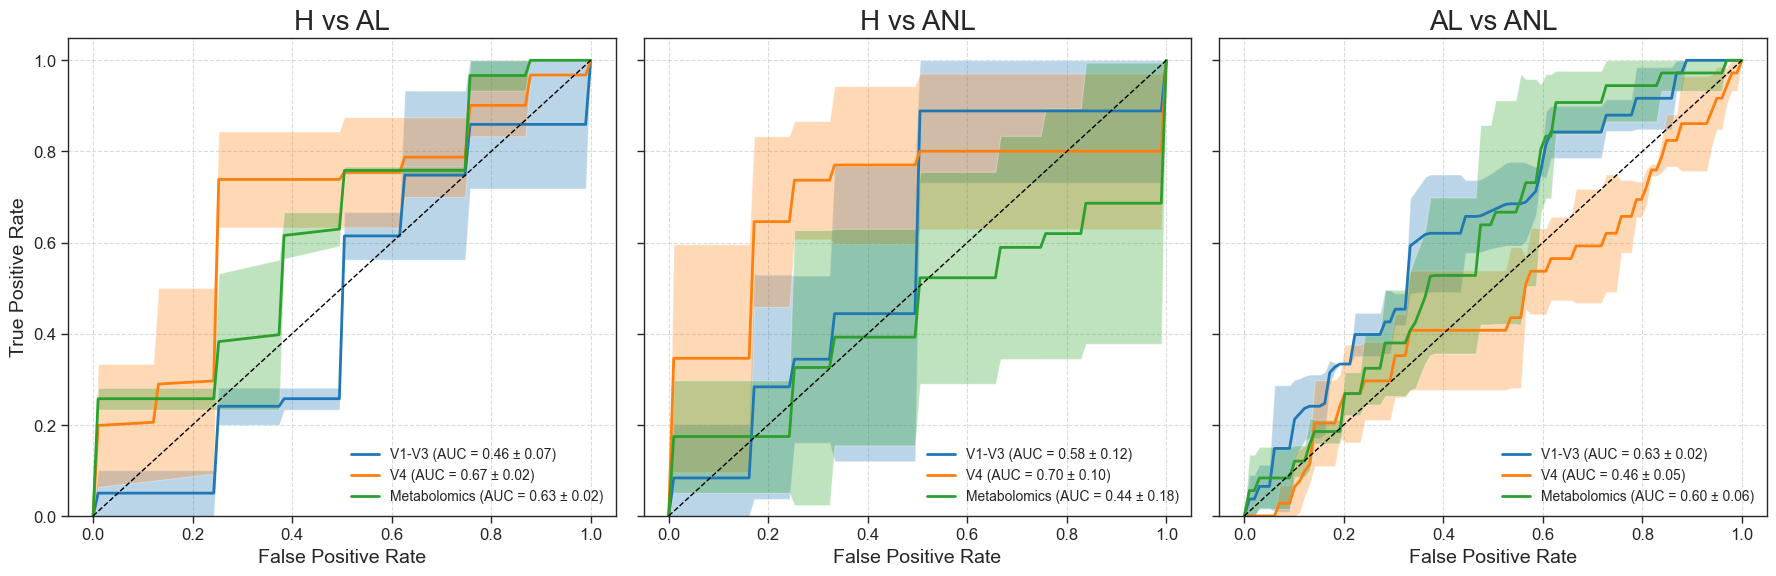

In [28]:
# Custom function for group-stratified k-fold
def group_stratified_kfold(X, y, groups, n_splits=5, random_state=42):
    """
    Custom implementation of cross-validation that respects both groups and stratification
    
    Parameters:
    -----------
    X : DataFrame
        Feature matrix
    y : Series
        Target labels
    groups : Series
        Group labels for samples (e.g., host_subject_id)
    n_splits : int
        Number of folds
    random_state : int
        Random seed
    
    Returns:
    --------
    list of tuples
        Each tuple contains (train_indices, test_indices)
    """
    # Get unique groups
    unique_groups = np.unique(groups)
    np.random.seed(random_state)
    np.random.shuffle(unique_groups)
    
    # Create label distribution per group
    group_label_dist = {}
    for group in unique_groups:
        group_mask = groups == group
        group_y = y[group_mask]
        group_label_dist[group] = {label: np.sum(group_y == label) for label in np.unique(y)}
    
    # Initialize folds with empty lists
    folds = [[] for _ in range(n_splits)]
    
    # Track current distribution of labels in each fold
    fold_label_dist = [{label: 0 for label in np.unique(y)} for _ in range(n_splits)]
    
    # Sort groups by size (number of samples) in descending order to place larger groups first
    sorted_groups = sorted(unique_groups, key=lambda g: sum(groups == g), reverse=True)
    
    # Assign groups to folds
    for group in sorted_groups:
        # Calculate which fold would benefit most from this group
        # by minimizing the imbalance across all labels
        best_fold = 0
        min_imbalance = float('inf')
        
        group_size = sum(groups == group)
        
        for fold_idx in range(n_splits):
            # Calculate current imbalance if we add this group
            temp_fold_dist = fold_label_dist[fold_idx].copy()
            for label, count in group_label_dist[group].items():
                temp_fold_dist[label] += count
            
            # Calculate imbalance as variance of label proportions
            fold_size = sum(temp_fold_dist.values())
            if fold_size == 0:
                proportions = [0] * len(temp_fold_dist)
            else:
                proportions = [count / fold_size for count in temp_fold_dist.values()]
            
            imbalance = np.var(proportions) + fold_size / (sum(groups.shape) / n_splits)
            
            if imbalance < min_imbalance:
                min_imbalance = imbalance
                best_fold = fold_idx
        
        # Assign group to best fold
        folds[best_fold].extend(np.where(groups == group)[0])
        # Update fold distribution
        for label, count in group_label_dist[group].items():
            fold_label_dist[best_fold][label] += count
    
    # Create train/test indices
    train_test_indices = []
    for i in range(n_splits):
        test_idx = np.array(folds[i])
        train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != i])
        train_test_indices.append((train_idx, test_idx))
    
    return train_test_indices

# Modified function to run group-stratified cross-validation with feature importance
def run_group_stratified_cv(X, y, groups, n_splits=5):
    # Get group-stratified folds
    folds = group_stratified_kfold(X, y, groups, n_splits=n_splits)
    
    # Initialize arrays to store results
    cv_results = []
    feature_importances = pd.DataFrame(index=X.columns)
    fold_aucs = []
    
    # Run cross-validation
    for i, (train_idx, test_idx) in enumerate(folds):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Handle cases where train set might contain only one class
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            print(f"Skipping fold {i+1} due to insufficient class representation")
            continue
            
        # Train classifier
        clf = RandomForestClassifier(n_estimators=1000, random_state=42)
        clf.fit(X_train, y_train)
        
        # Predict probabilities
        probas = clf.predict_proba(X_test)
        
        # Store feature importance for this fold
        feature_importances[f'fold_{i}'] = clf.feature_importances_
        
        # Store results
        fpr, tpr, _ = roc_curve(y_test, probas[:, 1])
        roc_auc = auc(fpr, tpr)
        fold_aucs.append(roc_auc)
        
        cv_results.append({
            'y_true': y_test,
            'y_proba': probas[:, 1],
            'fpr': fpr,
            'tpr': tpr,
            'auc': roc_auc,
            'fold': i
        })
    
    # Calculate mean feature importance across folds
    feature_importances['mean_importance'] = feature_importances.mean(axis=1)
    feature_importances['std_importance'] = feature_importances.std(axis=1)
    feature_importances = feature_importances.sort_values('mean_importance', ascending=False)
    
    return cv_results, feature_importances, fold_aucs

# Function to compute and plot ROC curves with error bars plus perform pairwise comparisons
def plot_roc_curves_with_comparisons(tables_dict, metadata, pair_comparisons, n_splits=5):
    num_tables = len(tables_dict)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    
    # Dictionary to store feature importances and AUCs for each method
    all_feature_importances = {}
    all_fold_aucs = {}
    
    # For each pairwise comparison
    for i, (label1, label2) in enumerate(pair_comparisons):
        ax = axs[i]
        
        # Plot title
        ax.set_title(f'{label1} vs {label2}', fontsize=20)
        comparison_key = f'{label1}_vs_{label2}'
        all_feature_importances[comparison_key] = {}
        all_fold_aucs[comparison_key] = {}
        
        # For each data table
        for table_name, table in tables_dict.items():
            # Get samples with either label1 or label2
            # meta_subset = metadata[metadata['label'].isin([label1, label2])]
            
            # Get data table samples that match the metadata subset
            common_samples = table.index.intersection(metadata.index)
            X = table.loc[common_samples]
            meta_filtered = metadata.loc[common_samples]
            
            # Skip if insufficient samples
            if len(common_samples) < 10:
                print(f"Skipping {table_name} for {label1} vs {label2}: insufficient samples ({len(common_samples)})")
                continue
                
            meta_subset = metadata[metadata['label'].isin([label1, label2])]
            common_samples = table.index.intersection(meta_subset.index)

            X = table.loc[common_samples]
            meta_filtered = meta_subset.loc[common_samples]

            # Create binary labels (0 for label1, 1 for label2)
            y = meta_filtered['label'].map({label1: 0, label2: 1})
            
            # Get subject IDs for grouping
            groups = meta_filtered['host_subject_id']
            
            # Run CV with group stratification
            cv_results, feature_imp, fold_aucs = run_group_stratified_cv(X, y, groups, n_splits=n_splits)
            
            # Store results
            all_feature_importances[comparison_key][table_name] = feature_imp
            all_fold_aucs[comparison_key][table_name] = fold_aucs
            
            # Skip if not enough results
            if len(cv_results) < 2:
                print(f"Skipping {table_name} for {label1} vs {label2}: CV returned insufficient results")
                continue
            
            # Interpolate all ROC curves to a common set of FPR points
            mean_fpr = np.linspace(0, 1, 100)
            tprs = []
            aucs = []
            
            for result in cv_results:
                tprs.append(interp(mean_fpr, result['fpr'], result['tpr']))
                tprs[-1][0] = 0.0
                aucs.append(result['auc'])
            
            # Calculate mean and std of TPR
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)
            std_tpr = np.std(tprs, axis=0)
            
            # Calculate upper and lower bounds for shaded region
            tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
            tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
            
            # Plot mean ROC curve
            ax.plot(mean_fpr, mean_tpr, lw=2, 
                   label=f'{table_name} (AUC = {mean_auc:.2f} ± {std_auc:.2f})')
            
            # Plot shaded region for error bars
            ax.fill_between(mean_fpr, tprs_lower, tprs_upper, alpha=0.3)
        
        # Add diagonal line
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        
        # Customize plot
        ax.set_xlabel('False Positive Rate', fontsize=14)
        if i == 0:
            ax.set_ylabel('True Positive Rate', fontsize=14)

        ax.set_ylim([0.0, 1.05])
        ax.tick_params(axis='both', which='major', labelsize=12)
        ax.grid(True, linestyle='--', alpha=0.7)
        
        # Add legend for each subplot
        ax.legend(loc='lower right', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    
    # Perform pairwise statistical tests on fold AUCs
    pairwise_comparisons = compute_pairwise_comparisons(all_fold_aucs)
    
    return fig, all_feature_importances, pairwise_comparisons

# Function to perform pairwise statistical tests
def compute_pairwise_comparisons(fold_aucs_dict):
    """
    Perform pairwise statistical tests between methods for each task
    
    Parameters:
    -----------
    fold_aucs_dict : dict
        Dictionary with fold-wise AUC values for each method
    
    Returns:
    --------
    DataFrame
        Table with pairwise comparisons and p-values
    """
    results = []
    
    for task, methods_dict in fold_aucs_dict.items():
        # Get list of methods that have AUC values
        methods = list(methods_dict.keys())
        
        # Perform pairwise comparisons
        for method1, method2 in combinations(methods, 2):
            # Get AUC values for both methods
            aucs1 = methods_dict[method1]
            aucs2 = methods_dict[method2]
            
            # Ensure equal length (use only common folds)
            min_len = min(len(aucs1), len(aucs2))
            if min_len < 2:
                continue
                
            aucs1 = aucs1[:min_len]
            aucs2 = aucs2[:min_len]
            
            # Calculate mean AUCs
            mean_auc1 = np.mean(aucs1)
            mean_auc2 = np.mean(aucs2)
            diff_auc = mean_auc1 - mean_auc2
            
            # Perform statistical tests
            # Wilcoxon signed-rank test (non-parametric)
            try:
                _, p_wilcoxon = wilcoxon(aucs1, aucs2)
            except:
                p_wilcoxon = np.nan
                
            # Paired t-test (parametric)
            _, p_ttest = ttest_rel(aucs1, aucs2)
            
            # Store results
            results.append({
                'Task': task,
                'Method 1': method1,
                'Method 2': method2,
                'Mean AUC 1': mean_auc1,
                'Mean AUC 2': mean_auc2,
                'AUC Difference': diff_auc,
                'p-value (Wilcoxon)': p_wilcoxon,
                'p-value (t-test)': p_ttest,
                'Significant (p<0.05)': (p_wilcoxon < 0.05) if not np.isnan(p_wilcoxon) else (p_ttest < 0.05)
            })
    
    # Create DataFrame
    results_df = pd.DataFrame(results)
    
    return results_df

# Create a dictionary of tables
tables = {
    'V1-V3': v3_table,
    'V4': v4_table,
    'Metabolomics': metabolomics_table
}

# Define pairwise comparisons
comparisons = [('H', 'AL'), ('H', 'ANL'), ('AL', 'ANL')]

# Set number of CV splits
n_cv_splits = 3

# Run analysis and plot
fig, feature_importances, pairwise_stats = plot_roc_curves_with_comparisons(tables, metadata, comparisons, n_splits=n_cv_splits)

# Display pairwise performance comparison table
print("\n" + "="*80)
print("Pairwise Performance Comparison of Methods")
print("="*80)
print(pairwise_stats.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Display the top 10 most important features for each comparison and data type
for comparison, data_types in feature_importances.items():
    print(f"\n{'='*50}")
    print(f"Top 10 important features for {comparison}:")
    print(f"{'='*50}")
    
    for data_type, features_df in data_types.items():
        print(f"\n{data_type}:")
        print("-" * 40)
        top_features = features_df.sort_values('mean_importance', ascending=False).head(10)
        print(top_features[['mean_importance', 'std_importance']])

plt.savefig('../Figures/Main/Figure_4/RF_ROC.png', dpi=600)
plt.show()

### Map features to taxonomy for 16S, and then compare between primer sets. 

In [29]:
def compare_feature_importances(feature_imp_dict, task, top_n=20):
    """
    Compare V1-V3 and V4 feature importances after collapsing ASVs
    to a shared taxonomic resolution (Taxon_label).

    Parameters:
    -----------
    feature_imp_dict : dict
        Dictionary containing feature importance results
    task : str
        Classification task (e.g., 'H_vs_AL')
    top_n : int
        Number of top taxa to show in heatmap
    """

    display_task = task.replace("_", " ")

    # Load ASV → Taxon mappings
    asv_to_taxon_v1v3 = (
        pd.read_csv(
            "../Data/16S/Taxonomy/ASV_to_Taxon_V1V3.tsv",
            sep="\t"
        )
        .set_index("ASV_sequence")["Taxon_label"]
    )

    asv_to_taxon_v4 = (
        pd.read_csv(
            "../Data/16S/Taxonomy/ASV_to_Taxon_V4.tsv",
            sep="\t"
        )
        .set_index("ASV_sequence")["Taxon_label"]
    )

    # Extract feature importances
    v1v3_imp = feature_imp_dict[task]["V1-V3"]
    v4_imp = feature_imp_dict[task]["V4"]

    # Collapse ASVs → Taxon
    def collapse_to_taxon(imp_df, asv_to_taxon):
        df = imp_df.copy()
        df["taxon"] = df.index.map(asv_to_taxon)
        df = df.dropna(subset=["taxon"])

        taxon_df = (
            df.groupby("taxon")["mean_importance"]
            .sum()
            .sort_values(ascending=False)
            .to_frame(name="importance")
            .reset_index()
        )

        taxon_df["rank"] = range(1, len(taxon_df) + 1)
        return taxon_df

    v1v3_taxon = collapse_to_taxon(v1v3_imp, asv_to_taxon_v1v3)
    v4_taxon = collapse_to_taxon(v4_imp, asv_to_taxon_v4)

    # Merge shared taxa
    merged_df = pd.merge(
        v1v3_taxon,
        v4_taxon,
        on="taxon",
        suffixes=("_v1v3", "_v4")
    )

    print(
        f"Number of overlapping taxa for {display_task}: "
        f"{merged_df.shape[0]}"
    )

    # Rank-based correlation
    spearman_r, p_spearman = spearmanr(
        merged_df["rank_v1v3"],
        merged_df["rank_v4"]
    )

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle(
        f"Feature Importance Comparison for {display_task}",
        fontsize=22,
        y=0.95
    )

    # Rank–rank plot
    sns.regplot(
        x="rank_v1v3",
        y="rank_v4",
        data=merged_df,
        scatter_kws={"alpha": 0.7, "s": 70},
        line_kws={"lw": 2.5},
        ax=ax1
    )

    ax1.text(
        0.05,
        0.85,
        f"Spearman ρ: {spearman_r:.3f} (p={p_spearman:.2e})",
        transform=ax1.transAxes,
        fontsize=14,
        bbox={'boxstyle': 'round', 'facecolor': 'white', 'alpha': 0.85}
    )

    ax1.set_title("Correlation of Taxon Importance Ranks", fontsize=18)

    ax1.set_xlabel("V1-V3 Taxon Rank", fontsize=14)
    ax1.set_ylabel("V4 Taxon Rank", fontsize=14)
    ax1.grid(True, linestyle="--", alpha=0.7)

    min_val = min(ax1.get_xlim()[0], ax1.get_ylim()[0])
    max_val = max(ax1.get_xlim()[1], ax1.get_ylim()[1])
    ax1.set_xlim([0, 38])
    ax1.set_ylim(min_val, max_val)

    # Heatmap of top taxa
    merged_df["avg_rank"] = (
        merged_df["rank_v1v3"] + merged_df["rank_v4"]
    ) / 2

    top_features = merged_df.sort_values("avg_rank").head(top_n)

    heatmap_data = pd.DataFrame(
        {
            "V1-V3 Rank": top_features["rank_v1v3"].values,
            "V4 Rank": top_features["rank_v4"].values,
        },
        index=top_features["taxon"],
    )

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".0f",
        cmap="viridis_r",
        linewidths=0.8,
        ax=ax2,
        cbar_kws={"label": "Rank (lower is better)", "shrink": 0.8},
    )

    ax2.set_title(
        f"Top {top_n} Taxa by Average Rank",
        fontsize=18
    )
    ax2.tick_params(axis="y", rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    out_path = (
        f"../Figures/Supplementary/"
        f"Suppl_Figure_8/RF_feature-importance_{task}.png"
    )

    plt.savefig(
        out_path,
        dpi=600,
        bbox_inches="tight"
    )
    plt.close(fig)

    return merged_df


In [30]:
# Run comparisons for all three classification tasks
tasks = ['H_vs_AL', 'H_vs_ANL', 'AL_vs_ANL']
comparison_results = {}

for task in tasks:
    print(f"\n{'='*60}\nAnalyzing {task.replace('_', ' ')} classification\n{'='*60}")
    if task in feature_importances and 'V1-V3' in feature_importances[task] and 'V4' in feature_importances[task]:
        comparison_results[task] = compare_feature_importances(feature_importances, task)
    else:
        print(f"Missing data for task {task}")


Analyzing H vs AL classification
Number of overlapping taxa for H vs AL: 31

Analyzing H vs ANL classification
Number of overlapping taxa for H vs ANL: 31

Analyzing AL vs ANL classification
Number of overlapping taxa for AL vs ANL: 31
